# 패키지 및 데이터 로드

In [5]:
# ─────────────────────────────────
# 기본 라이브러리
# ─────────────────────────────────
from hossam import *

import numpy as np
import seaborn as sb
from matplotlib import pyplot as plt
from pandas import DataFrame, concat

# ─────────────────────────────────
# scikit-learn: 파이프라인 / 데이터 분할
# ─────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)
from sklearn.preprocessing import StandardScaler

# ─────────────────────────────────
# scikit-learn: 로지스틱 회귀 모델
# ─────────────────────────────────
from sklearn.linear_model import LogisticRegression

# ─────────────────────────────────
# scikit-learn: 성능 평가 지표
# ─────────────────────────────────
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

# ─────────────────────────────────
# 기타 수학 / 기하 유틸
# ─────────────────────────────────
from scipy.spatial import ConvexHull


### 데이터 가져오기

In [6]:
# ── 데이터 로드
# origin = load_data("dogs")  # 기존 방식 (주석 처리)
origin = hs_util.load_data("dogs"
)

# ── 데이터 확인
origin.head()

닥스훈트와 진돗개의 몸 길이와 키를 조사한 가상 데이터

✅ 테이블 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dog     200 non-null    object 
 1   length  200 non-null    float64
 2   height  200 non-null    float64
dtypes: float64(2), object(1)
memory usage: 4.8+ KB


✅ 상위 5개 행
+---+-----+--------+--------+
|   | dog | length | height |
+---+-----+--------+--------+
| 0 |  d  | 55.01  | 29.27  |
| 1 |  d  | 59.01  | 29.39  |
| 2 |  d  | 56.53  |  28.5  |
| 3 |  d  | 53.66  |  28.5  |
| 4 |  d  | 49.67  | 31.97  |
+---+-----+--------+--------+

✅ 하위 5개 행
+-----+-----+--------+--------+
|     | dog | length | height |
+-----+-----+--------+--------+
| 195 |  j  | 50.95  | 52.37  |
| 196 |  j  | 51.86  |  52.4  |
| 197 |  j  | 54.24  | 47.82  |
| 198 |  j  | 53.13  | 50.22  |
| 199 |  j  |  53.0  | 51.18  |
+-----+-----+--------+--------+

📊 기술통계
+--------+-------+----------+

,dog,length,height
0,d,55.010,29.270
1,d,59.010,29.390
2,d,56.530,28.500
3,d,53.660,28.500
4,d,49.670,31.970


### 종속변수 타입 변환

 > 로지스틱은 종속변수가 명목형 변수이기 때문

In [8]:
df = origin.astype({"dog":"category"}) #타입이 object인 dog열을 category타입으로 변환
df.info() #결과 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   dog     200 non-null    category
 1   length  200 non-null    float64 
 2   height  200 non-null    float64 
dtypes: category(1), float64(2)
memory usage: 3.6 KB


# 데이터 품질 확인
## 연속형 데이터 확인

### 데이터 품질 확인 함수 정의

In [19]:
from pandas import DataFrame, concat
import numpy as np


def hs_describe(data, columns=None):
    """
    수치형 변수 요약 통계 + 결측/이상치/왜도 기반 분포 해석 함수
    """

    # ── 수치형 컬럼 자동 추출
    num_columns = list(data.select_dtypes(include=np.number).columns)

    if not columns:
        columns = num_columns

    # ── 기본 기술통계
    desc = data[columns].describe().T

    # ── 결측치 개수 / 비율
    na_counts = data[columns].isnull().sum()
    desc.insert(1, "na_count", na_counts)
    desc.insert(2, "na_rate", (na_counts / len(data)) * 100)

    # ── 추가 통계 저장용
    additional_stats = []

    for f in columns:
        # 수치형 변수만 처리
        if f not in num_columns:
            continue

        # ── 사분위수
        q1 = data[f].quantile(0.25)
        q3 = data[f].quantile(0.75)
        iqr = q3 - q1

        # ── 이상치 기준 (Tukey’s fences)
        down = q1 - 1.5 * iqr
        up = q3 + 1.5 * iqr

        # ── 왜도
        skew = data[f].skew()
        abs_skew = abs(skew)

        # ── 이상치 개수 / 비율
        outlier_count = ((data[f] < down) | (data[f] > up)).sum()
        outlier_rate = (outlier_count / len(data)) * 100

        # ── 분포 형태 해석
        if abs_skew < 0.5:
            dist = "거의 대칭"
        elif abs_skew < 1.0:
            dist = "약한 우측 꼬리" if skew > 0 else "약한 좌측 꼬리"
        elif abs_skew < 2.0:
            dist = "중간 우측 꼬리" if skew > 0 else "중간 좌측 꼬리"
        else:
            dist = "극단 우측 꼬리" if skew > 0 else "극단 좌측 꼬리"

        # ── 로그 변환 필요성 판단
        if abs_skew < 0.5:
            log_need = "낮음"
        elif abs_skew < 1.0:
            log_need = "중간"
        else:
            log_need = "높음"

        additional_stats.append({
            "field": f,
            "iqr": iqr,
            "down": down,
            "up": up,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_rate,
            "skew": skew,
            "dist": dist,
            "log_need": log_need,
        })

    # ── 추가 통계 DataFrame
    additional_df = DataFrame(additional_stats).set_index("field")

    # ── 결과 병합
    result = concat([desc, additional_df], axis=1)

    return result


 




### 데이터 품질 확인

In [20]:
hs_describe(df)

,count,na_count,na_rate,mean,std,min,25%,50%,75%,max,iqr,down,up,outlier_count,outlier_rate,skew,dist,log_need
length,200.000,0,0.000,53.795,5.506,39.940,50.222,53.445,56.900,68.310,6.678,40.206,66.916,3,1.500,0.224,거의 대칭,낮음
height,200.000,0,0.000,41.675,10.036,22.760,31.965,43.785,51.185,55.870,19.220,3.135,80.015,0,0.000,-0.170,거의 대칭,낮음


### 데이터 분포 확인

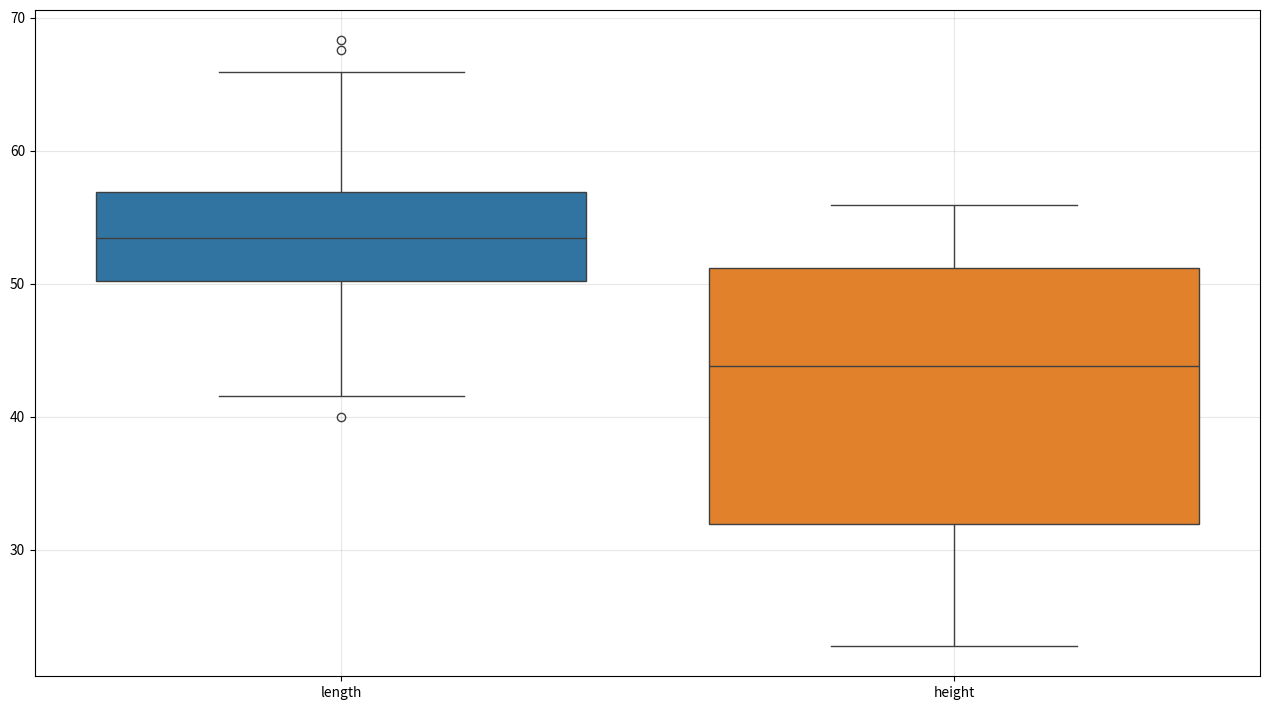

In [21]:
# DPI 설정
my_dpi = 100
figsize = (1280 / my_dpi, 720 / my_dpi)

# Figure 생성
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi,
)

# 박스플롯
sb.boxplot(
    data=origin,
    orient="v",
    ax=ax,
)

# 그리드
ax.grid(True, alpha=0.3)

# 출력
plt.tight_layout()
plt.show()
plt.close()


### 명목형 변수 품질 확인 함수 정의

In [48]:
origin["dog"].value_counts()

dog
d    100
j    100
Name: count, dtype: int64

In [64]:
def category_describe(data, columns=None):
    # 수치형 컬럼 목록
    num_columns = data.select_dtypes(include=np.number).columns

    # columns 미지정 시 → 범주형(object, category, bool) 자동 선택
    if not columns:
        columns = data.select_dtypes(
            include=["object", "category", "bool"]
        ).columns

    result = []
    summary = []

    for f in columns:
        # 숫자형 컬럼은 건너뜀
        if f in num_columns:
            continue

        # 범주별 빈도 (NaN 포함)
        value_counts = data[f].value_counts(dropna=False)

        # 컬럼에 값이 하나도 없으면 skip
        if len(value_counts) == 0:
            continue

        # ─────────────────────────────
        # 범주별 상세 테이블
        # ─────────────────────────────
        for category, count in value_counts.items():
            rate = (count / len(data)) * 100
            result.append({
                "변수": f,
                "범주": category,
                "빈도": count,
                "비율(%)": round(rate, 2),
            })

        # ─────────────────────────────
        # 최대 / 최소 범주 요약
        # ─────────────────────────────
        max_category = value_counts.index[0]  
        max_count = value_counts.iloc[0]   
        max_rate = (max_count / len(data)) * 100

        min_category = value_counts.index[-1] #맨 마지막 행에 접근?
        min_count = value_counts.iloc[-1]  
        min_rate = (min_count / len(data)) * 100

        #d는 d의 값끼리, j는 j의 값끼리

        summary.append({
            "변수": f,
            "최대_범주": max_category,
            "최대_비율(%)": round(max_rate, 2),
            "최소_범주": min_category,
            "최소_비율(%)": round(min_rate, 2),
        })

    return (
        DataFrame(result),
        DataFrame(summary).set_index("변수"),
    )


In [ ]:
# dogs의 
origin["dog"].value_counts

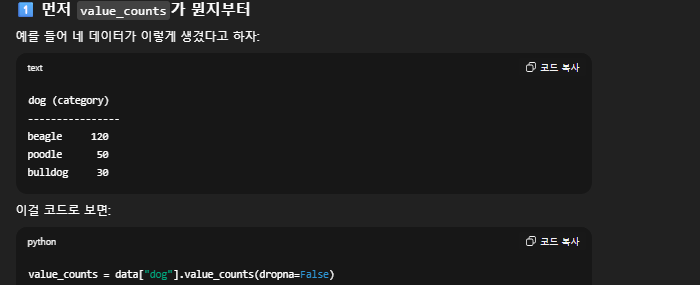<br>
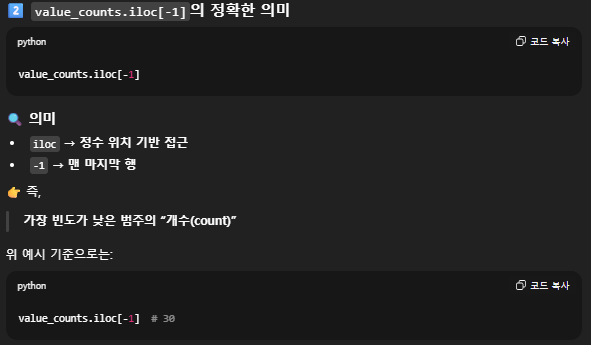<br>
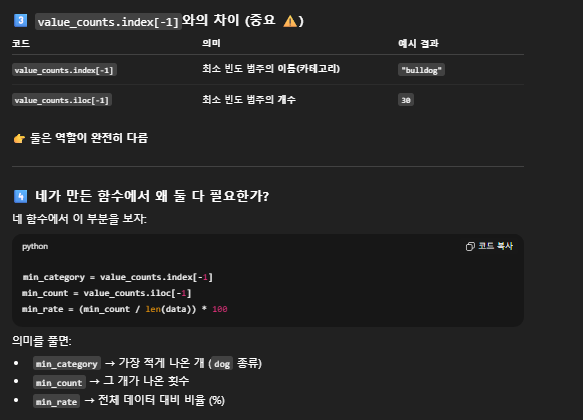<br>
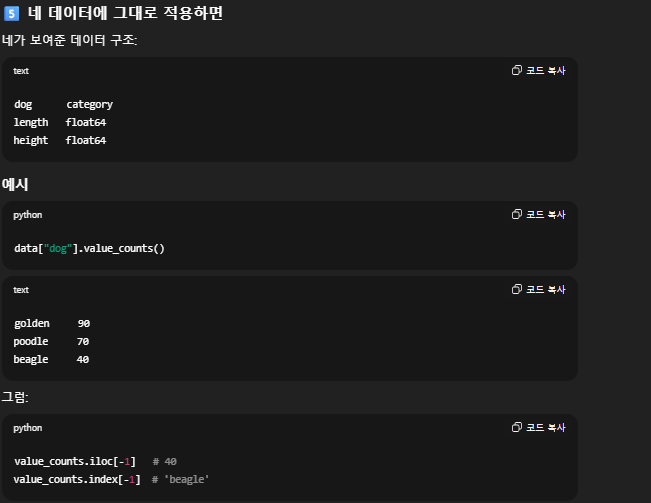<br>


### 명목형 품질 확인

In [47]:
a, b = category_describe(df)
display(a)
display(b)

,변수,범주,빈도,비율(%)
0,dog,d,100,50.000
1,dog,j,100,50.000


,최대_범주,최대_비율(%),최소_범주,최소_비율(%)
변수,,,,
dog,d,50.000,j,50.000


### 명목형 분포 시각화

In [1]:
vdf = df.copy()
hue_field = "dog"
x_field = "length"
y_field = "height"
my_dpi = 100

figsize = (1280/my_dpi, 720/ my_dpi)
fig, ax = plt.subplots(1,1, figxize = figsize, dpi = my_dpi)

# 군집별, 값의 종류별로 반복
for c in vdf[hue_field].unique():
    df_c = vdf.loc[vdf[hue_field] == c, [x_field, y_field]]
    
    try:
        hull = ConvexHull(df_c)
        points = np.append(hull.vertices, hull.vertices[0]) # 시작점과 끝점을 연결
        ax.plot(df_c.iloc[[points,0], df_c.iloc[points,1], linewidth = 0.5, linestyle =":"])
        ax.fill(df_c.iloc[points,0],df_c.iloc[points, 1], alpha=0.1)
    except:
        pass

sb.scatterplot(data=vdf, x=x_field, y=y_field, hue=hue_field)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (3746117861.py, line 17)

# 데이터 전처리

### 종속변수 라벨링

In [55]:
df2 = df.copy()
df2['dog']  = df2['dog'].map({'d':0, 'j':1})
display(df2.head())
df2.info()

,dog,length,height
0,0,55.010,29.270
1,0,59.010,29.390
2,0,56.530,28.500
3,0,53.660,28.500
4,0,49.670,31.970


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   dog     200 non-null    category
 1   length  200 non-null    float64 
 2   height  200 non-null    float64 
dtypes: category(1), float64(2)
memory usage: 3.6 KB


### 훈련, 검증 데이터 분리

In [59]:
df3 = df2 

# 종속변수 분리
yname = "dog"
X = df3.drop(columns=[yname])
y = df3[yname]


X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.25, random_state = 52)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((150, 2), (50, 2), (150,), (50,))

# 로지스틱 회귀 모형 적합

In [63]:
pip = Pipeline([("VIF_Selector", VIFSelector()),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(random_state=52))])

param_grid = {
    "model__penalty":["12"],
    "model_solver":["lbfgs"],
    "model__max__iter" : [100,300,500],
    "model__class__weight":[None, "balanced"]

}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

gs.fit(X_train, y_train)

estimator = gs.best_estimator_
estimator

NameError: name 'pipe' is not defined

### 검증데이터를 통한 추정값 생성

In [ ]:
y_pred = estimator.predict(x_test)
y_pred

### 결과 시각화

In [ ]:
vdf = df4.copy()

hue_field = "y_pred"
x_field = "length"
y_field = "height"

figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# ── Convex Hull 경계선 그림
for c in vdf[hue_field].unique():

    # 각 클래스별 데이터프레임
    df_c = vdf.loc[vdf[hue_field] == c, [x_field, y_field]]

    try:
        hull = ConvexHull(df_c)

        # 마지막 점 → 첫 점으로 연결 (닫힌 다각형)
        points = np.append(hull.vertices, hull.vertices[0])

        ax.plot(
            df_c.iloc[points, 0],
            df_c.iloc[points, 1],
            linewidth=0.5,
            linestyle=":",
            alpha=0.1,
        )

    except Exception:
        pass

# ── 산점도
sb.scatterplot(
    data=vdf,
    x=x_field,
    y=y_field,
    hue=hue_field,
    ax=ax,
)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()
